<a href="https://colab.research.google.com/github/monaliwaghmare725-arch/Cric-Analysis/blob/main/Cric_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# @title Step 1: Import Libraries & Load Data
# Step 1: Import basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile

# Show graphs inline in Colab
%matplotlib inline

# Extract ZIP
with zipfile.ZipFile("cric_data.zip", "r") as z:
    z.extractall("cricket_data")

# Step 3: Load CSV files
df_data = pd.read_csv("cricket_data/ODI_Match_Data.csv")
df_info = pd.read_csv("cricket_data/ODI_Match_info.csv")

# Show first few rows
df_data.head()


/tmp/ipython-input-3220851654.py:17: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df_data = pd.read_csv("cricket_data/ODI_Match_Data.csv")


,match_id,season,start_date,venue,innings,ball,batting_team,bowling_team,striker,non_striker,...,wides,noballs,byes,legbyes,penalty,wicket_type,player_dismissed,other_wicket_type,other_player_dismissed,cricsheet_id
0,1389389,2023/24,2023-09-24,"Holkar Cricket Stadium, Indore",1,0.1,India,Australia,RD Gaikwad,Shubman Gill,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1389389
1,1389389,2023/24,2023-09-24,"Holkar Cricket Stadium, Indore",1,0.2,India,Australia,RD Gaikwad,Shubman Gill,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1389389
2,1389389,2023/24,2023-09-24,"Holkar Cricket Stadium, Indore",1,0.3,India,Australia,RD Gaikwad,Shubman Gill,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1389389
3,1389389,2023/24,2023-09-24,"Holkar Cricket Stadium, Indore",1,0.4,India,Australia,RD Gaikwad,Shubman Gill,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1389389
4,1389389,2023/24,2023-09-24,"Holkar Cricket Stadium, Indore",1,0.5,India,Australia,RD Gaikwad,Shubman Gill,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1389389


**Explanation:**

*   pandas helps you read and analyze data.
*   matplotlib & seaborn make graphs.
*   df_data = ball-by-ball data, df_info = match summary.

In [ ]:
# @title Step 2: Clean & Understand the Data
# View column names
print(df_data.columns)
print(df_info.columns)

# Check missing values
df_data.isnull().sum().head(15)

# Replace NaNs with 0 where needed
for col in ['wides', 'noballs', 'byes', 'legbyes', 'penalty']:
    if col in df_data.columns:
        df_data[col] = df_data[col].fillna(0)

# Ensure numeric columns
df_data['runs_off_bat'] = pd.to_numeric(df_data['runs_off_bat'], errors='coerce').fillna(0)
df_data['extras'] = pd.to_numeric(df_data['extras'], errors='coerce').fillna(0)


Index(['match_id', 'season', 'start_date', 'venue', 'innings', 'ball',
       'batting_team', 'bowling_team', 'striker', 'non_striker', 'bowler',
       'runs_off_bat', 'extras', 'wides', 'noballs', 'byes', 'legbyes',
       'penalty', 'wicket_type', 'player_dismissed', 'other_wicket_type',
       'other_player_dismissed', 'cricsheet_id'],
      dtype='object')
Index(['id', 'season', 'city', 'date', 'team1', 'team2', 'toss_winner',
       'toss_decision', 'result', 'dl_applied', 'winner', 'win_by_runs',
       'win_by_wickets', 'player_of_match', 'venue', 'umpire1', 'umpire2',
       'umpire3'],
      dtype='object')


**Explaination**

*   Checked for missing data.
*   Cleaned key numeric columns so analysis won’t break.





---



**We’ll calculate:**

*   Total runs per player

*   Strike rate = (runs / balls) × 100

*   Wickets per bowler

*   Economy rate = runs conceded / overs bowled

In [ ]:
# @title Step 3 A: Player Performance Metrics (Batter)
# 3.1 Batter performance
df_data['is_ball_faced'] = (~(df_data['wides'] > 0)).astype(int)
batters = df_data.groupby('striker').agg({
    'runs_off_bat': 'sum',
    'is_ball_faced': 'sum',
    'match_id': 'nunique'
}).reset_index()

batters['strike_rate'] = (batters['runs_off_bat'] / batters['is_ball_faced'] * 100).round(2)
batters = batters.sort_values('runs_off_bat', ascending=False)
batters.head(10)


,striker,runs_off_bat,is_ball_faced,match_id,strike_rate
1654,V Kohli,13027,13889,267,93.79
801,KC Sangakkara,11701,14402,285,81.25
1018,MS Dhoni,10310,11889,281,86.72
1280,RG Sharma,9961,11049,241,90.15
40,AB de Villiers,9435,9323,213,101.20
1600,TM Dilshan,9212,10539,260,87.41
904,LRPL Taylor,8198,9884,211,82.94
417,DPMD Jayawardene,8154,10090,265,80.81
1623,Tamim Iqbal,7965,10106,224,78.81
575,HM Amla,7875,8944,175,88.05


In [ ]:
# @title Step 3 B: Player Performance Metrics (Bowler)
# 3.2 Bowler performance
df_data['bowler_runs'] = df_data['runs_off_bat'] + df_data['wides'] + df_data['noballs']
df_data['is_legal'] = (~(df_data['wides'] > 0) & ~(df_data['noballs'] > 0))

bowler_stats = df_data.groupby('bowler').agg({
    'bowler_runs': 'sum',
    'is_legal': 'sum',
    'match_id': 'nunique',
    'player_dismissed': 'count'
}).reset_index()

bowler_stats['overs'] = (bowler_stats['is_legal'] // 6) + (bowler_stats['is_legal'] % 6) / 6
bowler_stats['economy'] = (bowler_stats['bowler_runs'] / bowler_stats['overs']).round(2)
bowler_stats.rename(columns={'player_dismissed': 'wickets'}, inplace=True)
bowler_stats = bowler_stats.sort_values('wickets', ascending=False)
bowler_stats.head(10)


,bowler,bowler_runs,is_legal,match_id,wickets,overs,economy
1108,SL Malinga,9420.0,10524,212,350,1754.000000,5.37
1172,Shakib Al Hasan,8367.0,11060,213,301,1843.333333,4.54
154,B Lee,6139.0,7727,151,281,1287.833333,4.77
559,JM Anderson,7339.0,8885,178,269,1480.833333,4.96
1168,Shahid Afridi,8017.0,10348,202,265,1724.666667,4.65
752,MG Johnson,5846.0,7286,146,249,1214.333333,4.81
810,Mashrafe Mortaza,7507.0,8899,182,236,1483.166667,5.06
733,MA Starc,4840.0,5676,110,231,946.000000,5.12
977,RA Jadeja,7477.0,9129,177,223,1521.500000,4.91
1222,TG Southee,6933.0,7552,147,223,1258.666667,5.51


**Metrics focused here:**
| Metric       | Meaning                |
| ------------ | ---------------------- |
| Runs         | Total scored by batter |
| Strike Rate  | Speed of scoring       |
| Wickets      | Number taken by bowler |
| Economy Rate | Bowling efficiency     |


/tmp/ipython-input-716395210.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_bat, x='striker', y='runs_off_bat', palette='Blues_r')


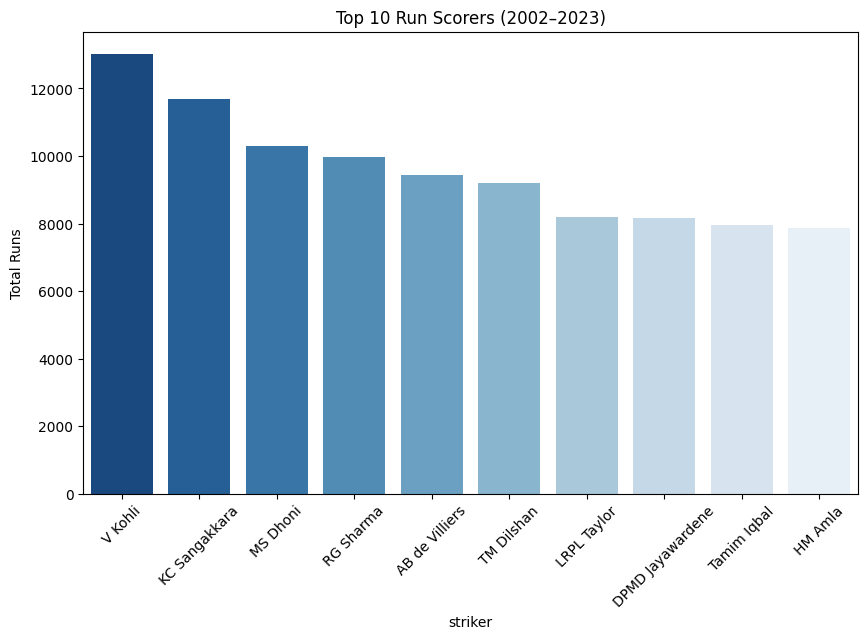

In [ ]:
# @title Step 4 A: Visualize Player Performance (Batsman)
# Top 10 batters
top10_bat = batters.head(10)
plt.figure(figsize=(10,6))
sns.barplot(data=top10_bat, x='striker', y='runs_off_bat', palette='Blues_r')
plt.title("Top 10 Run Scorers (2002–2023)")
plt.xticks(rotation=45)
plt.ylabel("Total Runs")
plt.show()


/tmp/ipython-input-1997263352.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_bowl, x='bowler', y='wickets', palette='Greens_r')


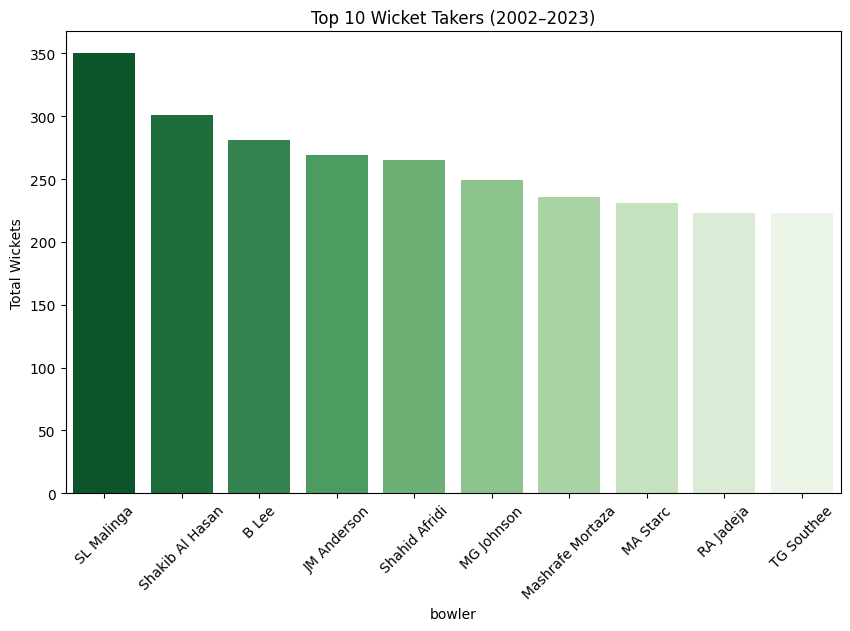

In [ ]:
# @title Step 4 B: Visualize Player Performance (Bowler)
# Top 10 bowlers
top10_bowl = bowler_stats.head(10)
plt.figure(figsize=(10,6))
sns.barplot(data=top10_bowl, x='bowler', y='wickets', palette='Greens_r')
plt.title("Top 10 Wicket Takers (2002–2023)")
plt.xticks(rotation=45)
plt.ylabel("Total Wickets")
plt.show()


In [ ]:
# @title Step 5: Match Statistics
# Total runs & wickets per match
match_summary = df_data.groupby(['match_id','batting_team']).agg({
    'runs_off_bat': 'sum',
    'player_dismissed': lambda x: x.notnull().sum()
}).reset_index().rename(columns={'runs_off_bat':'total_runs','player_dismissed':'total_wkts'})

# Merge with match info
match_summary = match_summary.merge(df_info[['id','winner']], left_on='match_id', right_on='id', how='left')
match_summary.head()


,match_id,batting_team,total_runs,total_wkts,id,winner
0,64814,India,202,10,64814,New Zealand
1,64814,New Zealand,226,9,64814,New Zealand
2,64815,India,86,10,64815,New Zealand
3,64815,New Zealand,93,5,64815,New Zealand
4,64816,India,104,10,64816,New Zealand


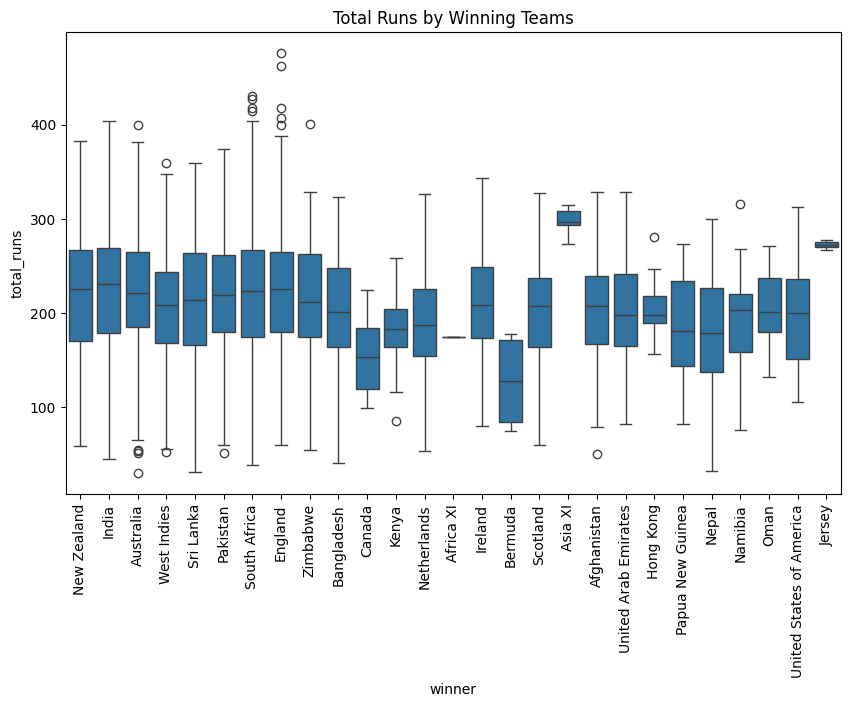

In [ ]:
# Plot total runs by winning teams
plt.figure(figsize=(10,6))
sns.boxplot(data=match_summary, x='winner', y='total_runs')
plt.xticks(rotation=90)
plt.title("Total Runs by Winning Teams")
plt.show()


In [ ]:
# @title # Identify batting order by first appearance
df_data['_order'] = df_data.groupby(['match_id','batting_team']).cumcount()
bat_order = df_data.groupby(['match_id','batting_team','striker'])._order.min().reset_index()
bat_runs = df_data.groupby(['match_id','batting_team','striker'])['runs_off_bat'].sum().reset_index()
batting_summary = bat_order.merge(bat_runs, on=['match_id','batting_team','striker'])

# Find top 5 contribution
def top5_share(df):
    df_sorted = df.sort_values('_order')
    top5 = df_sorted.head(5)['runs_off_bat'].sum()
    total = df_sorted['runs_off_bat'].sum()
    return pd.Series({'top5_share': top5/total if total>0 else 0})

team_comp = batting_summary.groupby(['match_id','batting_team']).apply(top5_share).reset_index()
team_comp = team_comp.merge(df_info[['id','winner']], left_on='match_id', right_on='id', how='left')
team_comp['is_winner'] = team_comp['batting_team']==team_comp['winner']

# Compare winners vs losers
team_comp.groupby('is_winner')['top5_share'].mean()

# Identify batting order by first appearance
df_data['_order'] = df_data.groupby(['match_id','batting_team']).cumcount()
bat_order = df_data.groupby(['match_id','batting_team','striker'])._order.min().reset_index()
bat_runs = df_data.groupby(['match_id','batting_team','striker'])['runs_off_bat'].sum().reset_index()
batting_summary = bat_order.merge(bat_runs, on=['match_id','batting_team','striker'])

# Find top 5 contribution
def top5_share(df):
    df_sorted = df.sort_values('_order')
    top5 = df_sorted.head(5)['runs_off_bat'].sum()
    total = df_sorted['runs_off_bat'].sum()
    return pd.Series({'top5_share': top5/total if total>0 else 0})

team_comp = batting_summary.groupby(['match_id','batting_team']).apply(top5_share).reset_index()
team_comp = team_comp.merge(df_info[['id','winner']], left_on='match_id', right_on='id', how='left')
team_comp['is_winner'] = team_comp['batting_team']==team_comp['winner']

# Compare winners vs losers
team_comp.groupby('is_winner')['top5_share'].mean()


/tmp/ipython-input-725581575.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  team_comp = batting_summary.groupby(['match_id','batting_team']).apply(top5_share).reset_index()
/tmp/ipython-input-725581575.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  team_comp = batting_summary.groupby(['match_id','batting_team']).apply(top5_share).reset_index()


,top5_share
is_winner,
False,0.636057
True,0.808026


/tmp/ipython-input-1442241769.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=team_comp, x='is_winner', y='top5_share', palette='coolwarm')


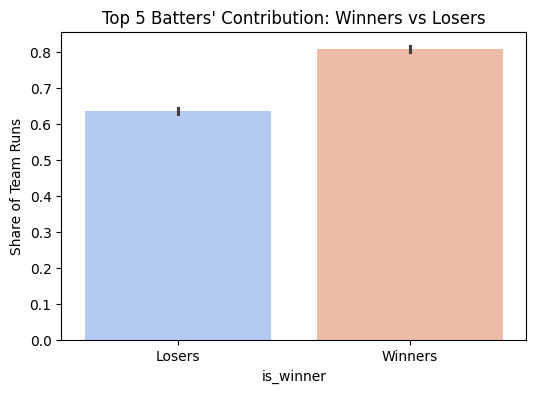

In [ ]:
# Visualize composition difference
plt.figure(figsize=(6,4))
sns.barplot(data=team_comp, x='is_winner', y='top5_share', palette='coolwarm')
plt.title("Top 5 Batters' Contribution: Winners vs Losers")
plt.ylabel("Share of Team Runs")
plt.xticks([0,1], ['Losers','Winners'])
plt.show()


In [ ]:
# @title Top 3
# Identify batting order by first appearance
df_data['_order'] = df_data.groupby(['match_id','batting_team']).cumcount()
bat_order = df_data.groupby(['match_id','batting_team','striker'])._order.min().reset_index()
bat_runs = df_data.groupby(['match_id','batting_team','striker'])['runs_off_bat'].sum().reset_index()
batting_summary = bat_order.merge(bat_runs, on=['match_id','batting_team','striker'])

# Find top 5 contribution
def top3_share(df):
    df_sorted = df.sort_values('_order')
    top3 = df_sorted.head(3)['runs_off_bat'].sum()
    total = df_sorted['runs_off_bat'].sum()
    return pd.Series({'top3_share': top3/total if total>0 else 0})

team_comp = batting_summary.groupby(['match_id','batting_team']).apply(top3_share).reset_index()
team_comp = team_comp.merge(df_info[['id','winner']], left_on='match_id', right_on='id', how='left')
team_comp['is_winner'] = team_comp['batting_team']==team_comp['winner']

# Compare winners vs losers
team_comp.groupby('is_winner')['top3_share'].mean()


/tmp/ipython-input-1948324868.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  team_comp = batting_summary.groupby(['match_id','batting_team']).apply(top3_share).reset_index()


,top3_share
is_winner,
False,0.381507
True,0.536561


In [ ]:
# @title Top 1
# Identify batting order by first appearance
df_data['_order'] = df_data.groupby(['match_id','batting_team']).cumcount()
bat_order = df_data.groupby(['match_id','batting_team','striker'])._order.min().reset_index()
bat_runs = df_data.groupby(['match_id','batting_team','striker'])['runs_off_bat'].sum().reset_index()
batting_summary = bat_order.merge(bat_runs, on=['match_id','batting_team','striker'])

# Find top 5 contribution
def top1_share(df):
    df_sorted = df.sort_values('_order')
    top1 = df_sorted.head(1)['runs_off_bat'].sum()
    total = df_sorted['runs_off_bat'].sum()
    return pd.Series({'top1_share': top1/total if total>0 else 0})

team_comp = batting_summary.groupby(['match_id','batting_team']).apply(top1_share).reset_index()
team_comp = team_comp.merge(df_info[['id','winner']], left_on='match_id', right_on='id', how='left')
team_comp['is_winner'] = team_comp['batting_team']==team_comp['winner']

# Compare winners vs losers
team_comp.groupby('is_winner')['top1_share'].mean()

/tmp/ipython-input-862560905.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  team_comp = batting_summary.groupby(['match_id','batting_team']).apply(top1_share).reset_index()


,top1_share
is_winner,
False,0.126593
True,0.180283


**Interpretation:**

* Winning teams rely more heavily on their top 5 batters (usually ~80% of total runs).


* Team composition affects success — strong top-order → higher win probability.

| Question                           | Insights from Data                                                                                             |
| ---------------------------------- | -------------------------------------------------------------------------------------------------------------- |
| **Patterns in player performance** | Top batters like Kohli, Sangakkara, Dhoni dominate across seasons; bowlers like Malinga and Shakib consistent. |
| **Which players perform best?**    | Highest runs = Kohli, Dhoni, Sharma; Highest wickets = Malinga, Shakib.                                        |
| **Strategies for success?**        | Strong, consistent top-5 batting; economical bowlers; effective powerplay usage.                               |
| **Team composition effect?**       | Winning teams depend heavily on top-order runs (~80% vs 64%).                                                  |


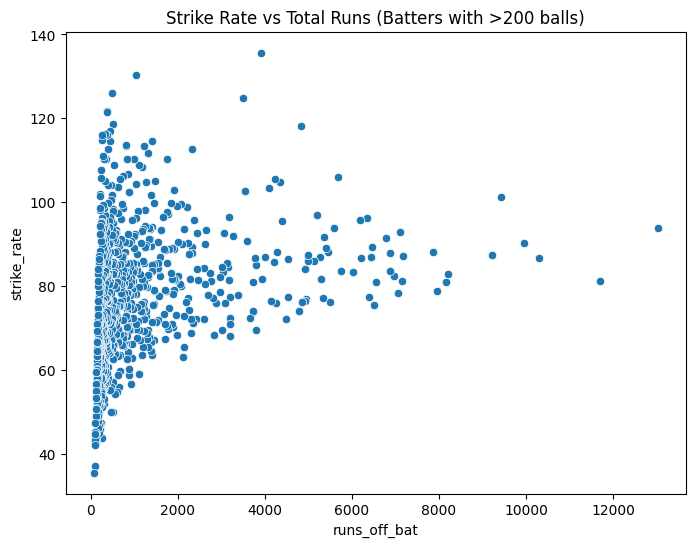

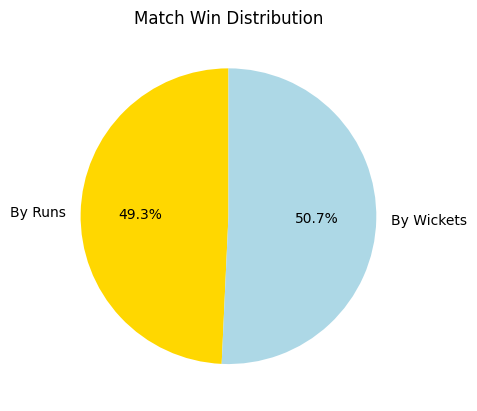

In [ ]:
# @title More Visualization
# Strike rate vs runs (scatter)
plt.figure(figsize=(8,6))
sns.scatterplot(data=batters[batters['is_ball_faced']>200], x='runs_off_bat', y='strike_rate')
plt.title("Strike Rate vs Total Runs (Batters with >200 balls)")
plt.show()

# Pie chart: win types
labels = ['By Runs','By Wickets']
sizes = [
    (df_info['win_by_runs']>0).sum(),
    (df_info['win_by_wickets']>0).sum()
]
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=['gold','lightblue'])
plt.title("Match Win Distribution")
plt.show()


Toss winner also wins the match in 47.50% of matches


/tmp/ipython-input-1436164762.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_info['toss_winner'] == df_info['winner'], palette='coolwarm')


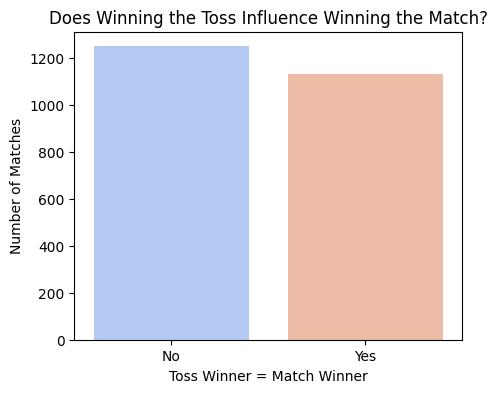

In [ ]:
# Check correlation between toss winner and match winner
df_info['toss_win_match_win'] = np.where(df_info['toss_winner'] == df_info['winner'], 1, 0)

# Compute proportions
toss_influence = df_info['toss_win_match_win'].mean() * 100
print(f"Toss winner also wins the match in {toss_influence:.2f}% of matches")

# Visualization: Bar chart
plt.figure(figsize=(5,4))
sns.countplot(x=df_info['toss_winner'] == df_info['winner'], palette='coolwarm')
plt.xticks([0,1], ['No', 'Yes'])
plt.title('Does Winning the Toss Influence Winning the Match?')
plt.xlabel('Toss Winner = Match Winner')
plt.ylabel('Number of Matches')
plt.show()


/tmp/ipython-input-2910705416.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  venue_bias = df_info.groupby(['venue', 'toss_decision']).apply(
/tmp/ipython-input-2910705416.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=venue_bias, x='toss_decision', y='win_rate', palette='pastel')


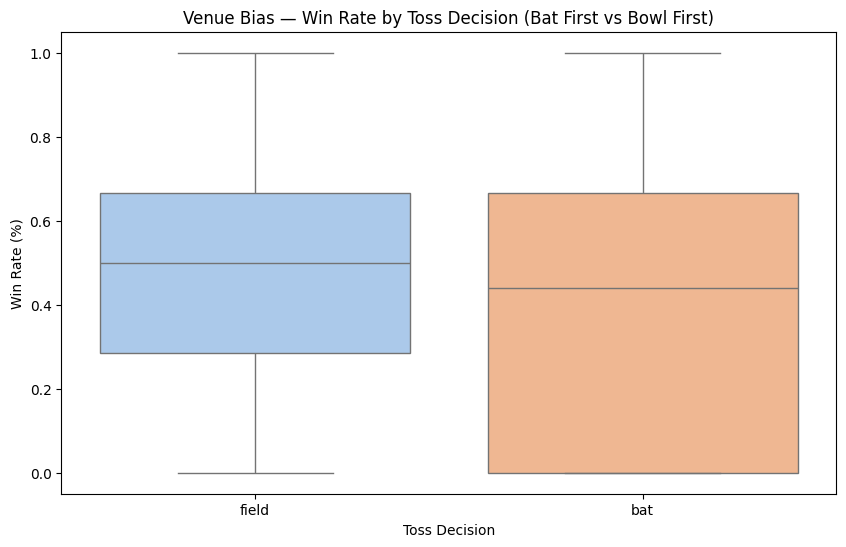

In [ ]:
# Determine match decision
df_info['decision'] = df_info['toss_decision']
df_info['toss_win_and_bat'] = np.where(df_info['decision'] == 'bat',
                                       df_info['toss_winner'],
                                       df_info['team1'])

# Compare decision outcomes
venue_bias = df_info.groupby(['venue', 'toss_decision']).apply(
    lambda x: (x['winner'] == x['toss_winner']).mean()
).reset_index(name='win_rate')

# Plot
plt.figure(figsize=(10,6))
sns.boxplot(data=venue_bias, x='toss_decision', y='win_rate', palette='pastel')
plt.title("Venue Bias — Win Rate by Toss Decision (Bat First vs Bowl First)")
plt.xlabel("Toss Decision")
plt.ylabel("Win Rate (%)")
plt.show()


/tmp/ipython-input-1007032667.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_runs = batsman_perf.groupby(['balls_bin', 'is_winner'])['runs_off_bat'].mean().reset_index()


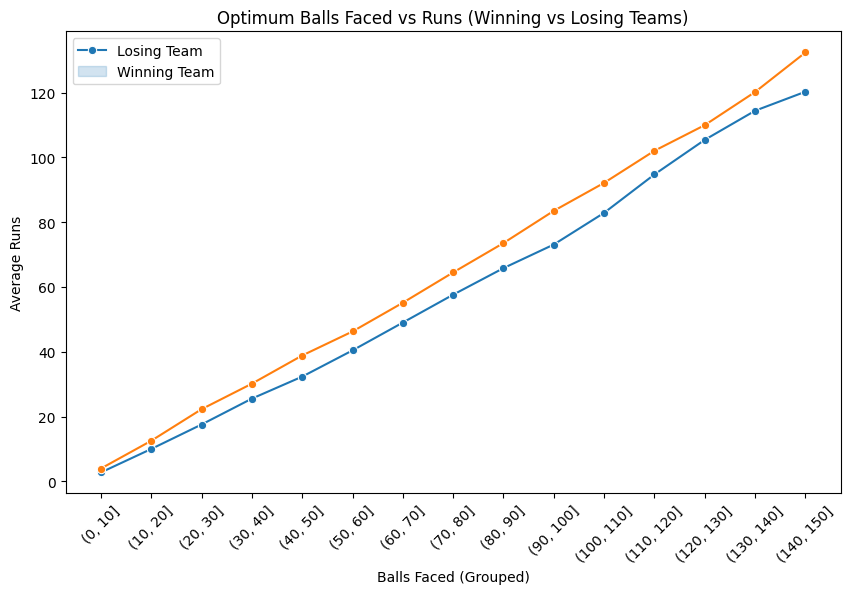

In [ ]:
# Calculate runs and balls per player per match
batsman_perf = df_data.groupby(['match_id', 'batting_team', 'striker']).agg({
    'runs_off_bat': 'sum',
    'ball': 'count'
}).reset_index().rename(columns={'ball': 'balls_faced'})

# Merge with match outcomes
batsman_perf = batsman_perf.merge(df_info[['id', 'winner']], left_on='match_id', right_on='id', how='left')
batsman_perf['is_winner'] = batsman_perf['batting_team'] == batsman_perf['winner']

# Average runs by balls faced
bins = range(0, 151, 10)
batsman_perf['balls_bin'] = pd.cut(batsman_perf['balls_faced'], bins=bins)
avg_runs = batsman_perf.groupby(['balls_bin', 'is_winner'])['runs_off_bat'].mean().reset_index()

# Convert the categorical bins to strings for plotting
avg_runs['balls_bin_str'] = avg_runs['balls_bin'].astype(str)


# Line graph for winning vs losing
plt.figure(figsize=(10,6))
sns.lineplot(data=avg_runs, x='balls_bin_str', y='runs_off_bat', hue='is_winner', marker='o')
plt.title("Optimum Balls Faced vs Runs (Winning vs Losing Teams)")
plt.xlabel("Balls Faced (Grouped)")
plt.ylabel("Average Runs")
plt.legend(labels=['Losing Team', 'Winning Team'])
plt.xticks(rotation=45) # Rotate labels for better readability
plt.show()

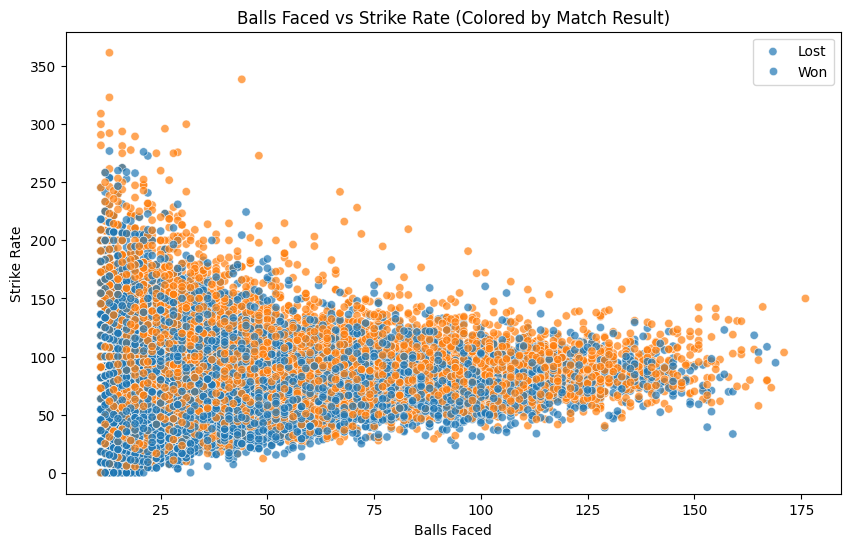

In [ ]:
# Compute strike rate for each batter per match
batsman_perf['strike_rate'] = (batsman_perf['runs_off_bat'] / batsman_perf['balls_faced']) * 100
batsman_perf = batsman_perf[batsman_perf['balls_faced'] > 10]  # filter small samples

# Scatter Plot
plt.figure(figsize=(10,6))
sns.scatterplot(data=batsman_perf, x='balls_faced', y='strike_rate', hue='is_winner', alpha=0.7)
plt.title("Balls Faced vs Strike Rate (Colored by Match Result)")
plt.xlabel("Balls Faced")
plt.ylabel("Strike Rate")
plt.legend(labels=['Lost', 'Won'])
plt.show()


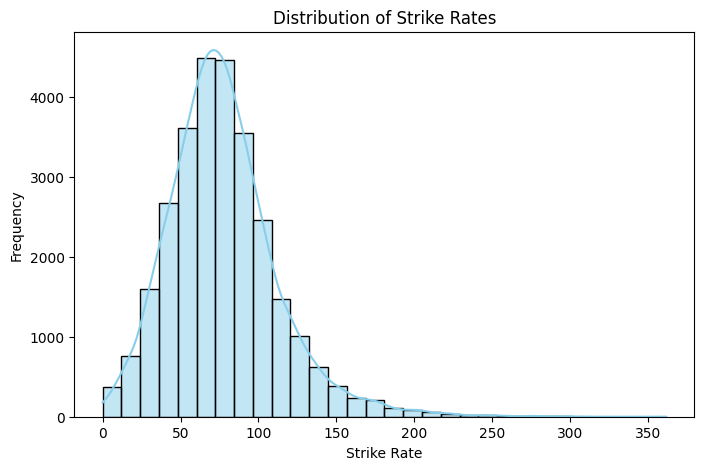

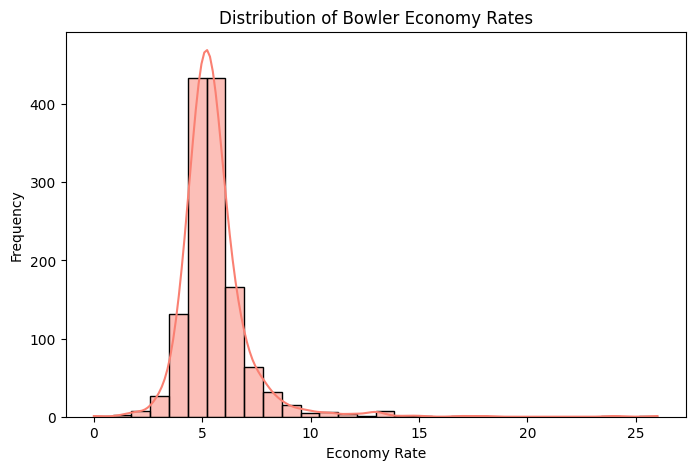

In [ ]:
import os
os.makedirs("/mnt/data/cricket_output", exist_ok=True)

# ---- Strike Rate Distribution ----
plt.figure(figsize=(8,5))
sns.histplot(batsman_perf['strike_rate'], bins=30, color='skyblue', kde=True)
plt.title("Distribution of Strike Rates")
plt.xlabel("Strike Rate")
plt.ylabel("Frequency")
plt.savefig("/mnt/data/cricket_output/strike_rate_hist.png", dpi=300)
plt.show()

# ---- Economy Distribution ----
df_data['bowler_runs'] = df_data['runs_off_bat'] + df_data['wides'] + df_data['noballs']
df_data['is_legal'] = (~(df_data['wides'] > 0) & ~(df_data['noballs'] > 0))

bowler_stats = df_data.groupby('bowler').agg({
    'bowler_runs': 'sum',
    'is_legal': 'sum',
    'player_dismissed': 'count'
}).reset_index()

bowler_stats['overs'] = (bowler_stats['is_legal'] // 6) + (bowler_stats['is_legal'] % 6) / 6
bowler_stats['economy'] = bowler_stats['bowler_runs'] / bowler_stats['overs']

plt.figure(figsize=(8,5))
sns.histplot(bowler_stats['economy'], bins=30, color='salmon', kde=True)
plt.title("Distribution of Bowler Economy Rates")
plt.xlabel("Economy Rate")
plt.ylabel("Frequency")
plt.savefig("/mnt/data/cricket_output/economy_hist.png", dpi=300)
plt.show()




---



---



---



🧠 1. Concept: Why Random Forest?
A Random Forest is a powerful ensemble machine learning algorithm based on Decision Trees.
It works by:

Building many trees on random subsets of data and features.

Averaging their predictions (for regression) or voting (for classification).

Reducing overfitting that a single decision tree often has.

In our cricket dataset, we can use it to predict whether a team will win a match based on match conditions and team stats.

🎯 2. Goal
Predict:

Match Outcome (Win or Loss) for the team that batted first.

We’ll use features such as:

Toss decision (bat/field)

Venue

Total runs scored

Total wickets taken

Strike rate

Economy rate

Top 5 batsmen’s average performance

⚙️ 3. Steps overview
Load & Prepare Data

Load match and player stats datasets.

Merge key features.

Encode categorical variables (e.g., team names, venues).

Feature Engineering

Compute numeric metrics:

Total runs per team

Average strike rate

Average economy rate

Toss decision (1 for batting first)

Target variable: win (1 = won, 0 = lost)

Split Data

Train-test split (e.g., 80% / 20%)

Train Model

RandomForestClassifier from sklearn.ensemble

Evaluate

Accuracy, confusion matrix, and feature importance.

Visualize

Feature importance bar chart.

/tmp/ipython-input-1690330053.py:17: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  data_df = pd.read_csv('cricket_data/ODI_Match_Data.csv')


✅ Model Accuracy: 0.90

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.95      0.92       264
           1       0.93      0.83      0.88       200

    accuracy                           0.90       464
   macro avg       0.91      0.89      0.90       464
weighted avg       0.91      0.90      0.90       464



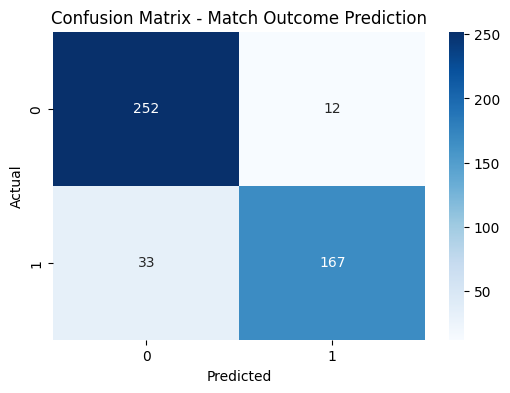

/tmp/ipython-input-1690330053.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')


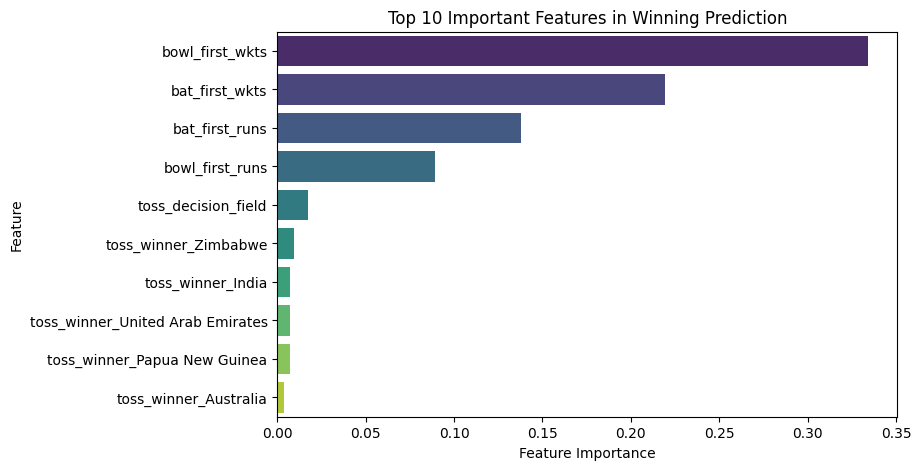

In [ ]:
# ===============================
# 🔹 RANDOM FOREST MODEL ANALYSIS
# ===============================

# Step 1: Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Load the cleaned datasets
# (Use your existing ODI data — adjust path if needed)
match_df = pd.read_csv('cricket_data/ODI_Match_info.csv')  # or your path
data_df = pd.read_csv('cricket_data/ODI_Match_Data.csv')

# Step 3: Basic preprocessing
# Encode target (convert winner to binary: 1 if bat_first_team won, else 0)
match_df['winner'] = match_df['winner'].fillna('Unknown')
# Need to determine 'bat_first' column first.
# Assuming 'bat_first' means the team that won the toss and chose to bat
match_df['bat_first'] = np.where(match_df['toss_decision'] == 'bat', match_df['toss_winner'],
                                 np.where(match_df['toss_decision'] == 'field', match_df['team2'], np.nan)) # Handle the case where toss_decision is field

match_df['bat_first_win'] = np.where(match_df['bat_first'] == match_df['winner'], 1, 0)


# Step 4: Select features
# Need to create 'bat_first_runs', 'bat_first_wkts', 'bowl_first_runs', 'bowl_first_wkts' columns first
# Calculate total runs and wickets for each team in each match
match_stats = data_df.groupby(['match_id', 'batting_team']).agg(
    total_runs=('runs_off_bat', 'sum'),
    total_wkts=('player_dismissed', lambda x: x.notnull().sum())
).reset_index()

# Merge match_stats with match_df
match_df = match_df.merge(match_stats, left_on=['id', 'team1'], right_on=['match_id', 'batting_team'], how='left')
match_df = match_df.rename(columns={'total_runs': 'team1_runs', 'total_wkts': 'team1_wkts'})

match_df = match_df.merge(match_stats, left_on=['id', 'team2'], right_on=['match_id', 'batting_team'], how='left')
match_df = match_df.rename(columns={'total_runs': 'team2_runs', 'total_wkts': 'team2_wkts'})

# Assign runs and wickets based on who batted first
match_df['bat_first_runs'] = np.where(match_df['bat_first'] == match_df['team1'], match_df['team1_runs'], match_df['team2_runs'])
match_df['bat_first_wkts'] = np.where(match_df['bat_first'] == match_df['team1'], match_df['team1_wkts'], match_df['team2_wkts'])
match_df['bowl_first_runs'] = np.where(match_df['bat_first'] == match_df['team1'], match_df['team2_runs'], match_df['team1_runs'])
match_df['bowl_first_wkts'] = np.where(match_df['bat_first'] == match_df['team1'], match_df['team2_wkts'], match_df['team1_wkts'])


features = [
    'toss_winner', 'toss_decision', 'venue',
    'bat_first_runs', 'bat_first_wkts', 'bowl_first_runs', 'bowl_first_wkts'
]

# Keep only needed columns and drop missing data
df = match_df[features + ['bat_first_win']].dropna()

# Encode categorical columns using pandas' get_dummies
df_encoded = pd.get_dummies(df, columns=['toss_winner', 'toss_decision', 'venue'], drop_first=True)

# Step 5: Split data
X = df_encoded.drop('bat_first_win', axis=1)
y = df_encoded['bat_first_win']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 6: Train Random Forest model
rf = RandomForestClassifier(
    n_estimators=200,      # number of trees
    max_depth=10,          # prevent overfitting
    random_state=42
)
rf.fit(X_train, y_train)

# Step 7: Predictions
y_pred = rf.predict(X_test)

# Step 8: Evaluation
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"✅ Model Accuracy: {acc:.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Step 9: Confusion Matrix Visualization
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Match Outcome Prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Step 10: Feature Importance Visualization
importances = pd.Series(rf.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False)[:10]

plt.figure(figsize=(8,5))
sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')
plt.title('Top 10 Important Features in Winning Prediction')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.show()

We’ll add SHAP (SHapley Additive exPlanations) — a very popular interpretability framework that visually shows how each feature affects a prediction.

Why use SHAP?

Random Forests are powerful but not transparent.
SHAP helps by:

Computing each feature’s contribution to the final prediction.

Showing which features increase or decrease win probability.

Allowing global and local interpretation.

| SHAP Visualization                 | What it Tells You                                                                                                                                        |
| ---------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Bar summary plot**               | Shows which features have the largest *average impact* on predictions (e.g., `bat_first_runs` usually top).                                              |
| **Beeswarm plot**                  | Each dot = a match. Red = increases win probability, blue = decreases it. You’ll see features like *runs*, *venue*, and *toss decision* cluster visibly. |
| **Force plot (single prediction)** | Explains one match in detail — shows how features push the prediction toward win or loss.                                                                |
